In [57]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

RMSE:  2.376659631729126


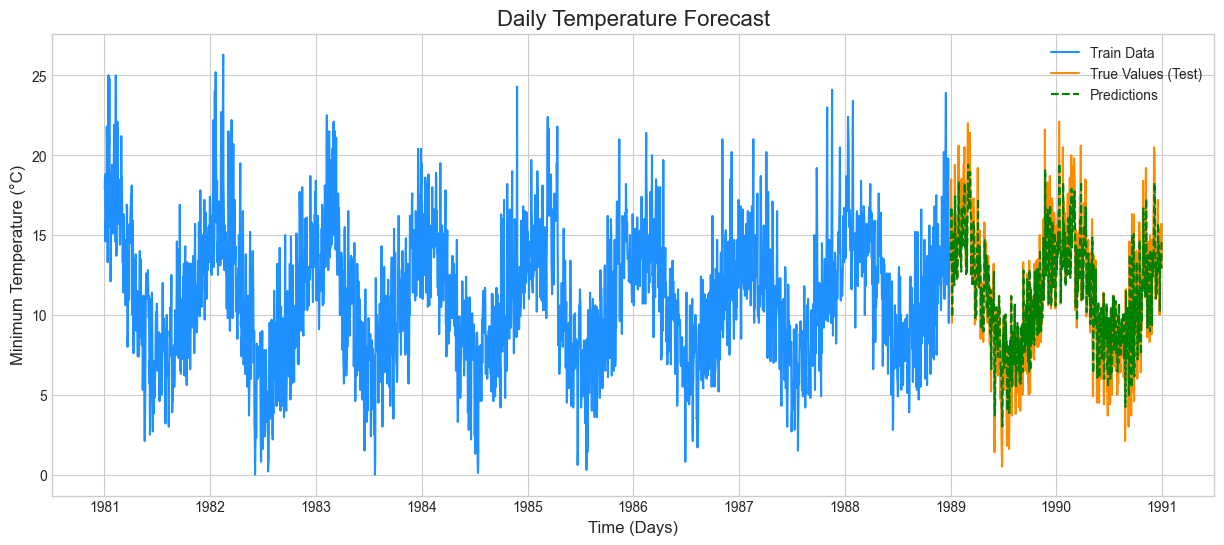

In [58]:
data = pd.read_csv('auto_regressive.csv', header=0, index_col=0, parse_dates=True)

y = data["Temp"]
X = torch.tensor(list(y[:-1])).reshape(-1, 1)
y = torch.tensor(list(y[1:])).reshape(-1, 1)
n = len(X)

# add the intercept term
X = torch.cat((torch.ones((n, 1)), X), dim=1)

X_train, y_train = X[:int(0.8*n)], y[:int(0.8*n)]
X_test, y_test = X[int(0.8*n):], y[int(0.8*n):]

# get theta
theta = torch.linalg.inv(X_train.T@X_train)@X_train.T@y_train

# get predictions
y_pred = X_test@theta
rmse = torch.sqrt(torch.mean((y_pred - y_test)**2))
print("RMSE: ", rmse.item())

# Plot everything
dates_ar = data.index[1:]
dates_train, dates_test = dates_ar[0:int(0.8*n)], dates_ar[int(0.8*n):]
plt.figure(figsize=(15, 6))
plt.plot(dates_train, y_train.numpy(), label='Train Data', color='dodgerblue')
plt.plot(dates_test, y_test.numpy(), label='True Values (Test)', color='darkorange')
plt.plot(dates_test, y_pred.numpy(), label='Predictions', color='green', linestyle='--')
plt.title('Daily Temperature Forecast', fontsize=16)
plt.xlabel('Time (Days)', fontsize=12) # Updated label
plt.ylabel('Minimum Temperature (°C)', fontsize=12)
plt.legend()
plt.show()